In [61]:
from qoolqit import Register

In [62]:
import numpy as np

Q = np.array([
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
])

QUBO problems are scale-invariant, and so we can work with the normalized matrix
$Q^{*} = \frac{Q}{max(Q)}$ instead.

Before showing how to solve this QUBO instance in the Rydberg analog model, we can compute the optimal solutions classically to compare. For that we do a brute force cost calculation over all possible bitstrings, which scales exponentially with the number of variables. This is only possible because we are dealing with a small QUBO.

In [63]:
#we can once again plot the exact solution. Cost different because Q has been normalized

# Normalize QUBO matrix
Q = Q/Q.max()

# Classical solution
bitstrings = np.array([np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))])
bitstring_lists = np.array([np.array(list(b), dtype=int) for b in bitstrings])
costs = np.array([z.T @ Q @ z for z in bitstring_lists])
idx_sort = np.argsort(costs).tolist()

sorted_costs = costs[idx_sort]
sorted_bitstrings = bitstrings[idx_sort]

print("Two best solutions: ", sorted_bitstrings[:2])
print("Respective costs: ", sorted_costs[:2])

# We save the two best solutions for plotting
marked_bitstrings = sorted_bitstrings[:2]

Two best solutions:  ['01011' '00111']
Respective costs:  [-1.31978679 -1.31978679]


To embed the QUBO problem in the Rydberg analog model, we can directly use a matrix embedding technique like the InteractionEmbedder. 

The InteractionEmbedder maps a matrix to a graph with node coordinates, from which we can directly instantiate a qubit register later.


This is the interrest of using Qoolqit, especially when you re new! If you are interested you can find here the available embedders and the philosophy of how to design a custom embedder https://docs.pasqal.com/qoolqit/qoolqitDoc/contents/available_embedders/
We can discuss it a bit if this is to your liking.

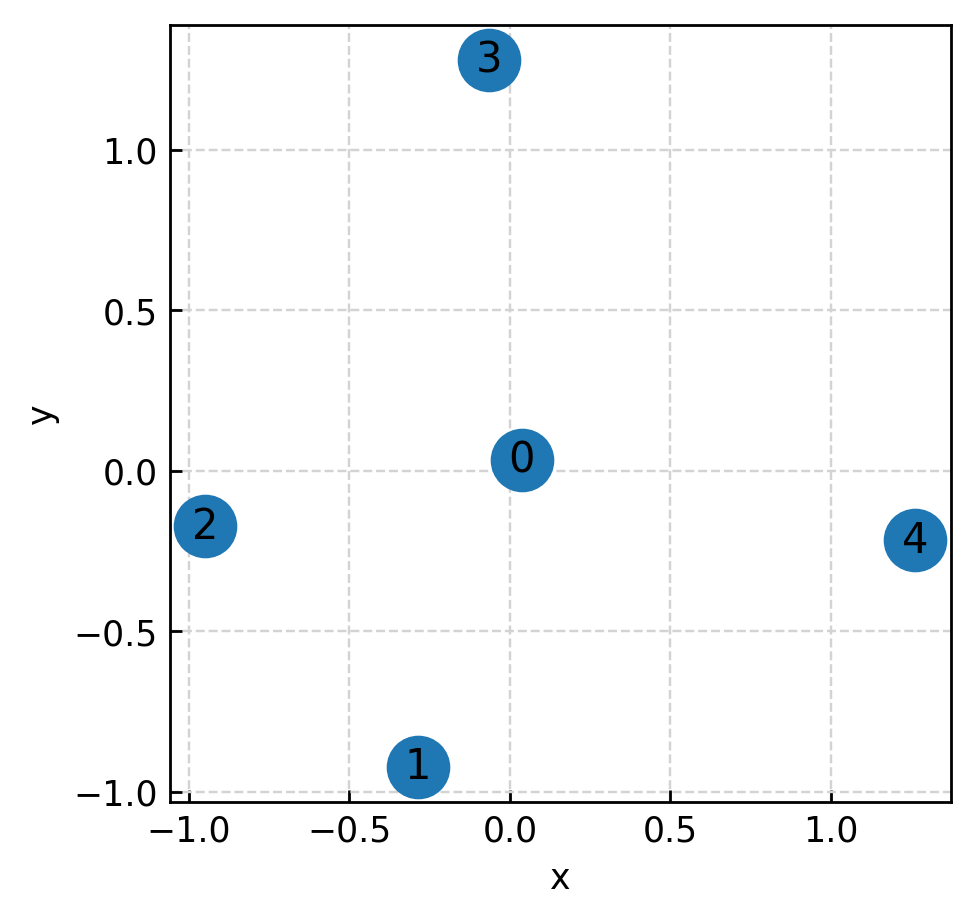

In [65]:
from qoolqit import InteractionEmbedder

embedder = InteractionEmbedder()
embedded_graph = embedder.embed(Q)
embedded_graph.draw()

Now we are going to write a similar program to the Pulser one, but with the qoolqit mindset.


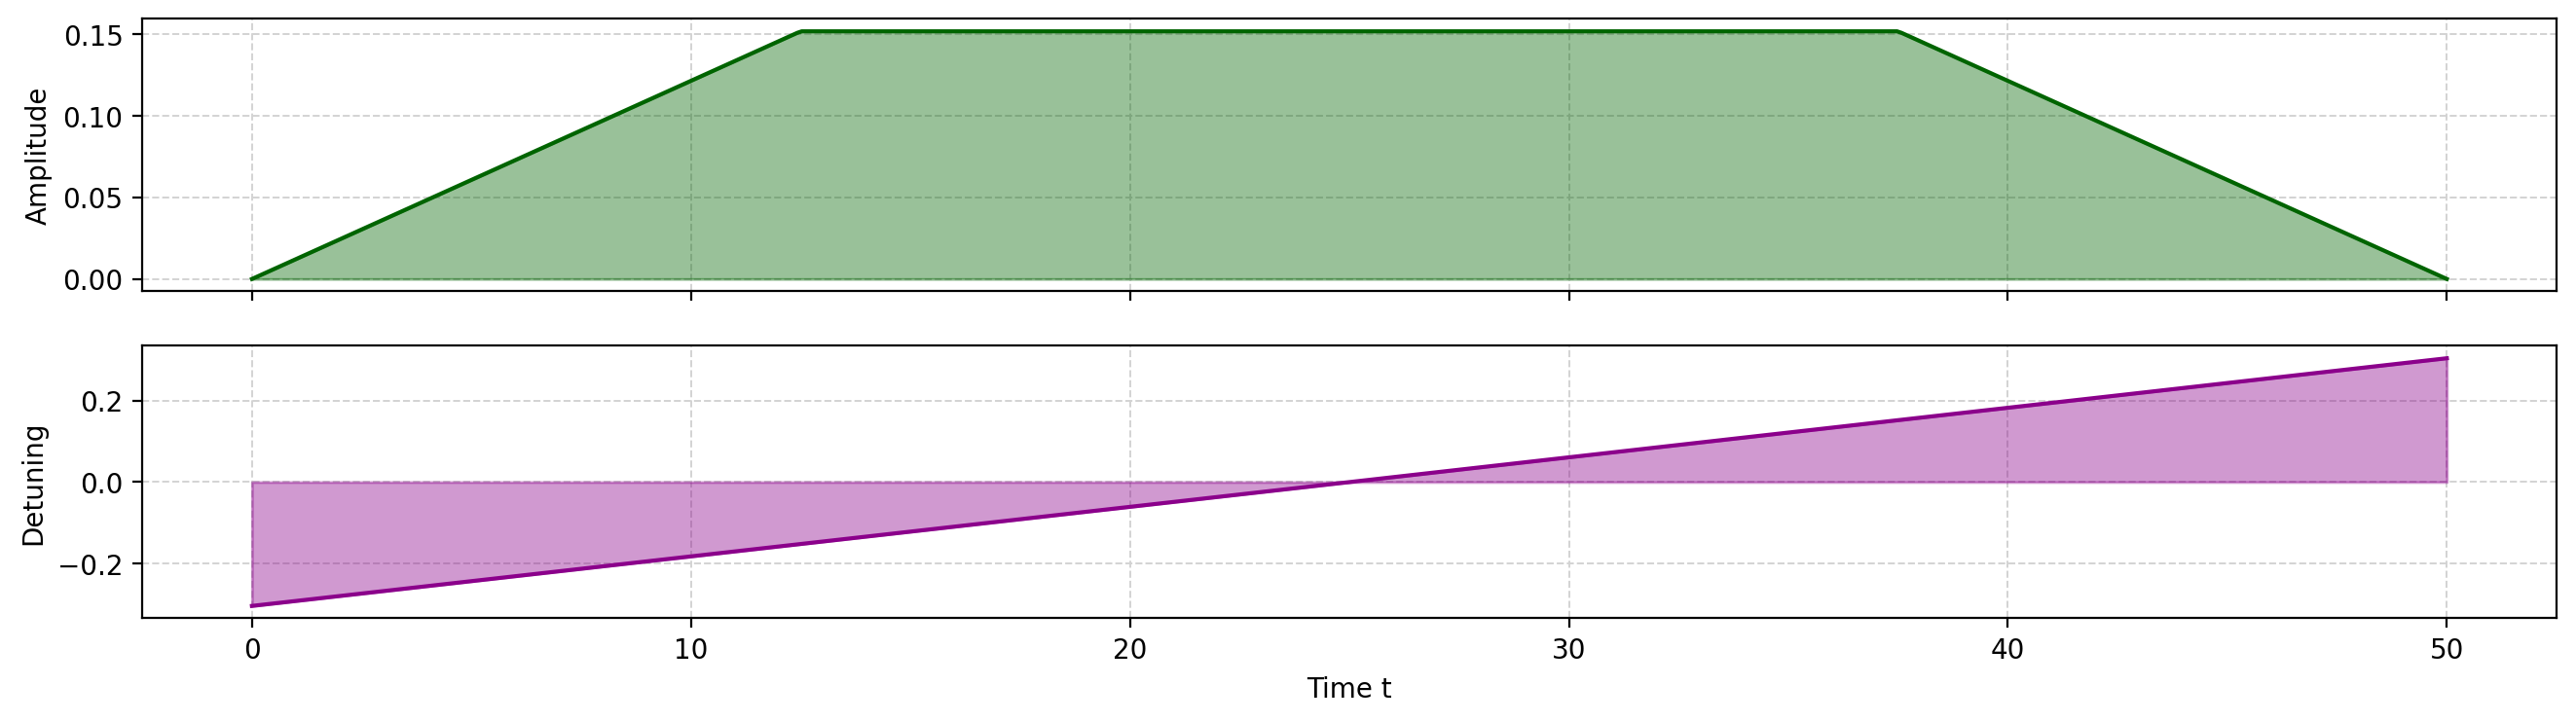

In [75]:
#Note that contrary to Pulser here you are not going to have dimensions in mind.

from qoolqit import Drive, PiecewiseLinear, QuantumProgram, Ramp, Register

# Create the register
register = Register.from_graph(embedded_graph)

# Defining the annealing parameters
omega = np.median(Q[Q > 0].flatten())
delta_i = -2.0 * omega
delta_f = 2.0 * omega
T = 50.0

# Defining the annealing schedule
wf_amp = PiecewiseLinear([T/4, T/2, T/4], [0.0, omega, omega, 0.0])
wf_det = Ramp(T, delta_i, delta_f)
drive = Drive(amplitude = wf_amp, detuning = wf_det)

#Note also that we are defining the annealing schedule in one go, we don t have to declare the channels then give their temporal profiles.

# Writing the quantum program
program = QuantumProgram(register, drive)
program.draw()

Here we are working on a QAA, thus the profile of the pulses

In [76]:
#Here we compile the program for a cetain device. This is the opposite of Pulser!
#Qoolqit will automatically try to find the best way to translate your adimensionnal programm to a specific set up.
#Be mindful, it might not be the optimal way for what you have in mind!
#Nonetheless a very good way to begin if you are not sure of what you re doing.

from qoolqit import AnalogDevice

program.compile_to(device = AnalogDevice())

The converter handles the logic of converting the adimensional QoolQit model to Pulser units. For theoretical details on how this conversion works between the Rydberg analog model and the implementation that Pulser uses you can check the Rydberg analog model page.

By default, each device creates a default converter where the energy unit is set as that device’s maximum amplitude.
This means that you still have to be careful to the other parameters size compared to the energy. You can for example see what happens if we take a time too big.

For more details on the unit conversion check https://docs.pasqal.com/qoolqit/qoolqitDoc/theory/rydberg_model/.




In [77]:
from qoolqit.execution import LocalEmulator

emulator = LocalEmulator(runs=500)

results = emulator.run(program)

counter = results[0].final_bitstrings
print(counter)

Counter({'00111': 205, '01011': 198, '00011': 23, '10000': 19, '00101': 13, '10001': 9, '00010': 9, '01010': 6, '00001': 6, '10010': 4, '01001': 3, '10011': 2, '01000': 1, '00100': 1, '00110': 1})


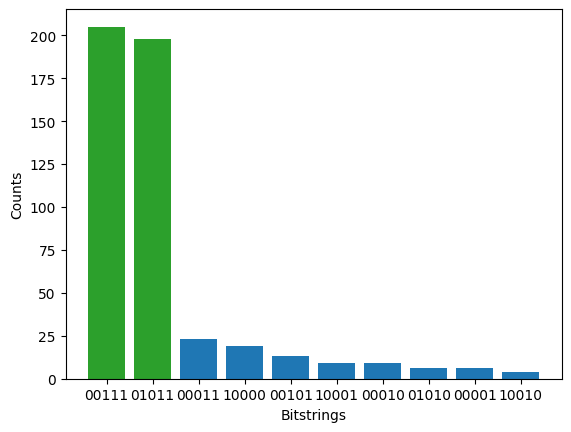

In [78]:
import matplotlib.pyplot as plt


def plot_distribution(counter, solutions, bins=10):
    counter = dict(counter.most_common(bins))
    color = ["tab:green" if key in solutions.tolist() else "tab:blue" for key in counter]
    fig, ax = plt.subplots()
    ax.set_xlabel("Bitstrings")
    ax.set_ylabel("Counts")
    ax.bar(range(len(counter)), counter.values(), color=color, tick_label=counter.keys())
    return fig

fig = plot_distribution(counter, marked_bitstrings)

We have similar results to the Pulser program! We could see once again what it does to not take a time long enough for the simulations.